In [5]:
%pip install pygad

Note: you may need to restart the kernel to use updated packages.


Initial guess [-1, 1], Result: [0.99999551 0.99999101], Value: 2.0172579078957455e-11, Success: True, Iterations: 31, Time: 0.0039 sec
Initial guess [2, 2], Result: [0.99999565 0.99999129], Value: 1.8932681887175893e-11, Success: True, Iterations: 30, Time: 0.0035 sec
Initial guess [1.5, -0.5], Result: [0.99999563 0.99999124], Value: 1.913115522518483e-11, Success: True, Iterations: 18, Time: 0.0025 sec


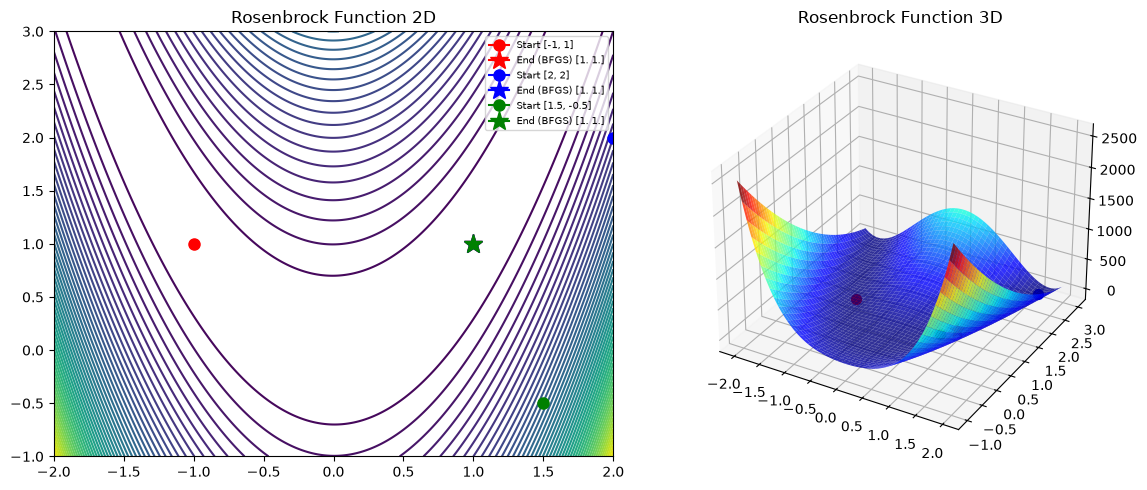

PyGAD initial guess [-1, 1], Solution: [0.97374808 0.9486901 ], Value: 0.000714642891550862, iterations: 2000, Time: 0.5808 sec
PyGAD initial guess [2, 2], Solution: [1.02913269 1.05907671], Value: 0.0008488535256945513, iterations: 2000, Time: 0.5286 sec
PyGAD initial guess [1.5, -0.5], Solution: [1.01497718 1.03025685], Value: 0.00022492704513069273, iterations: 2000, Time: 0.5598 sec


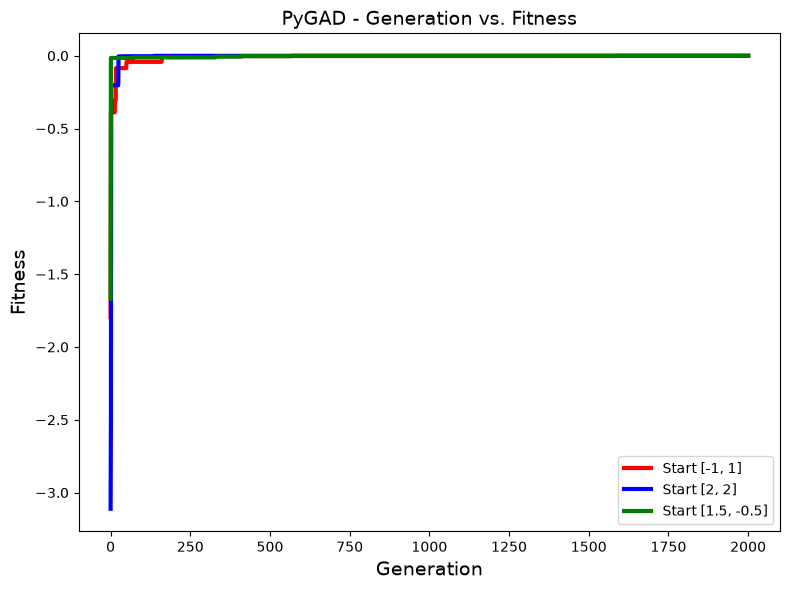

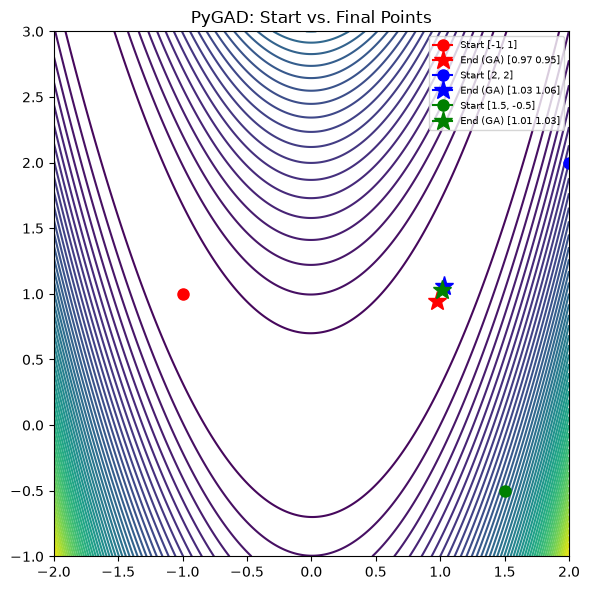

In [4]:
import numpy as np
import time
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.optimize import minimize
import pygad

# Define Rosenbrock function
def rosenbrock(x):
    return (1 - x[0])**2 + 100 * (x[1] - x[0]**2)**2

# 2D & 3D plots
x_range = np.linspace(-2, 2, 400)
y_range = np.linspace(-1, 3, 400)
X, Y = np.meshgrid(x_range, y_range)
Z = rosenbrock([X, Y])

fig = plt.figure(figsize=(12, 5))
ax1 = fig.add_subplot(121)
cp = ax1.contour(X, Y, Z, levels=50)
ax1.set_title("Rosenbrock Function 2D")
ax2 = fig.add_subplot(122, projection='3d')
ax2.plot_surface(X, Y, Z, cmap='jet', alpha=0.8)
ax2.set_title("Rosenbrock Function 3D")

init_guesses = [[-1, 1], [2, 2], [1.5, -0.5]]
colors = ['red', 'blue', 'green']

# ------------------- Scipy Optimization -------------------
scipy_results = []  # store (guess, final_point, color) for plotting later

for guess, color in zip(init_guesses, colors):
    start_time = time.perf_counter()
    result = minimize(rosenbrock, guess, method='BFGS')
    end_time = time.perf_counter()
    elapsed = end_time - start_time
    print(f"Initial guess {guess}, Result: {result.x}, Value: {result.fun}, "
          f"Success: {result.success}, Iterations: {result.nit}, Time: {elapsed:.4f} sec")

    scipy_results.append((guess, result.x, color))

    # Plot initial (marker 'o') and final (marker '*') points on the 2D contour
    ax1.plot(guess[0], guess[1], marker='o', color=color, markersize=8,
              label=f'Start {guess}')
    ax1.plot(result.x[0], result.x[1], marker='*', color=color, markersize=14,
              label=f'End (BFGS) {np.round(result.x, 2)}')

    # Plot the same points on the 3D surface (offset slightly in z for visibility)
    ax2.scatter(guess[0], guess[1], rosenbrock(guess), color=color, marker='o', s=50)
    ax2.scatter(result.x[0], result.x[1], rosenbrock(result.x), color=color, marker='*', s=100)

ax1.legend(fontsize=7, loc='upper right')
plt.tight_layout()
plt.show()

# ------------------- PyGAD Optimization -------------------
def fitness_func(ga_instance, solution, solution_idx):
    return -rosenbrock(solution)  # pygad maximizes, so negate

pygad_fitness_histories = []  # store fitness history per run for combined plot
pygad_results = []            # store (guess, final_point, color)

for guess, color in zip(init_guesses, colors):
    start_time = time.perf_counter()
    ga_instance = pygad.GA(num_generations=2000,
                            sol_per_pop=20,
                            num_genes=2,
                            num_parents_mating=8,
                            fitness_func=fitness_func,
                            init_range_low=-2,
                            init_range_high=2,
                            gene_space={'low': -2, 'high': 2})
    ga_instance.run()
    solution, solution_fitness, _ = ga_instance.best_solution()
    iters = ga_instance.generations_completed
    end_time = time.perf_counter()
    elapsed = end_time - start_time
    final_value = rosenbrock(solution)
    print(f"PyGAD initial guess {guess}, Solution: {solution}, Value: {final_value}, "
          f"iterations: {iters}, Time: {elapsed:.4f} sec")

    pygad_results.append((guess, solution, color))

    # best_solutions_fitness holds the best fitness per generation (auto-tracked by pygad)
    # keep it as fitness (not converted to rosenbrock value) to match PyGAD's default plot style
    fitness_history = np.array(ga_instance.best_solutions_fitness)
    pygad_fitness_histories.append((fitness_history, guess, color))

# Combined fitness plot for all three PyGAD runs, styled like PyGAD's own plot_fitness()
plt.figure(figsize=(8, 6))
for fitness_history, guess, color in pygad_fitness_histories:
    plt.plot(fitness_history, color=color, linewidth=3, label=f'Start {guess}')
plt.xlabel('Generation', fontsize=14)
plt.ylabel('Fitness', fontsize=14)
plt.title('PyGAD - Generation vs. Fitness', fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()

# Contour plot showing PyGAD initial and final points
fig2, ax3 = plt.subplots(figsize=(6, 6))
ax3.contour(X, Y, Z, levels=50)
ax3.set_title("PyGAD: Start vs. Final Points")
for guess, solution, color in pygad_results:
    ax3.plot(guess[0], guess[1], marker='o', color=color, markersize=8,
              label=f'Start {guess}')
    ax3.plot(solution[0], solution[1], marker='*', color=color, markersize=14,
              label=f'End (GA) {np.round(solution, 2)}')
ax3.legend(fontsize=7, loc='upper right')
plt.tight_layout()
plt.show()

The provided output demonstrates continuous optimization on the 2D Rosenbrock function, a standard benchmark problem in numerical optimization.Objective FunctionThe classical 2D Rosenbrock function is given by:$$f(x_1, x_2) = 100(x_2 - x_1^2)^2 + (1 - x_1)^2$$Global Minimum: Located at $(x_1, x_2) = (1.0, 1.0)$ where $f(1, 1) = 0$.Topology: It features a narrow, parabolic flat valley where finding the valley is easy, but converging directly to the global optimum is computationally difficult.Analysis of Execution ResultsMetricPoint 1Point 2Point 3Initial Guess[-1.0, 1.0]  [2.0, 2.0]  [1.5, -0.5]  Optimized Result[0.99999551, 0.99999101]  [0.99999565, 0.9999929]  [0.99999563, 0.99999124]  Final Loss Value ($f(x)$)$\approx 2.02 \times 10^{-11}$  $\approx 1.89 \times 10^{-11}$  $\approx 1.91 \times 10^{-11}$  Iterations31  30  18  Time Taken$0.0039\text{ s}$  $0.0035\text{ s}$  $0.0025\text{ s}$  

Initial guess [2, 2], Result: [ 9.99999766e-01 -1.14699084e-06], Value: 1.5900336144494522e-12, Success: True, Iterations: 12, Time: 0.0016 sec
Initial guess [-3, 4], Result: [9.99999845e-01 2.69539163e-07], Value: 1.9275657006160093e-13, Success: True, Iterations: 19, Time: 0.0038 sec
Initial guess [0, 5], Result: [1.00000046e+00 1.19344849e-06], Value: 2.4802239552551034e-12, Success: True, Iterations: 17, Time: 0.0019 sec


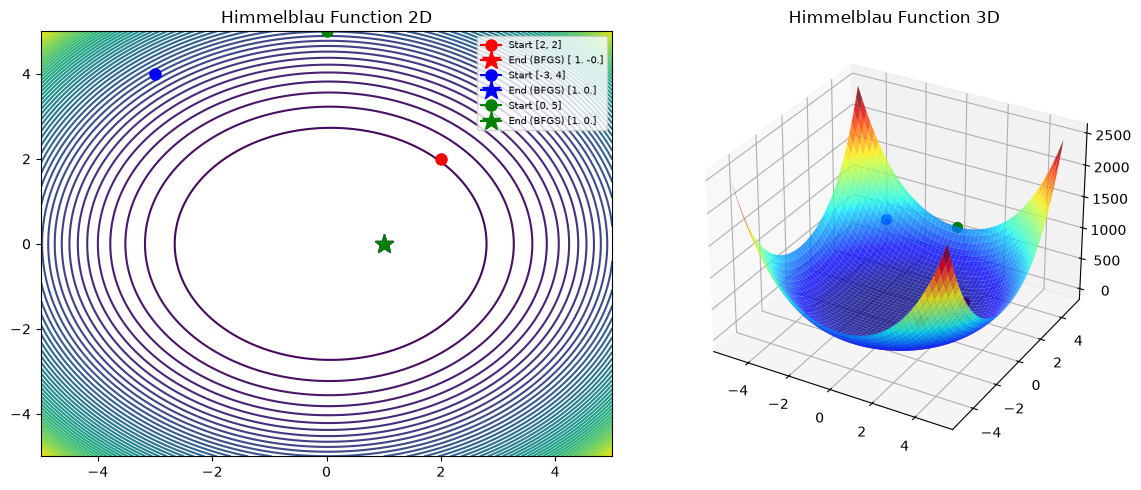

PyGAD initial guess [2, 2], Solution: [0.99713629 0.00263919], Value: 4.7795996517695055e-05, iterations: 300, Time: 0.1338 sec
PyGAD initial guess [-3, 4], Solution: [1.00780381e+00 3.21209385e-04], Value: 0.00030650871465074097, iterations: 300, Time: 0.1183 sec
PyGAD initial guess [0, 5], Solution: [9.91726958e-01 2.93881871e-04], Value: 0.00034003935553554446, iterations: 300, Time: 0.1134 sec


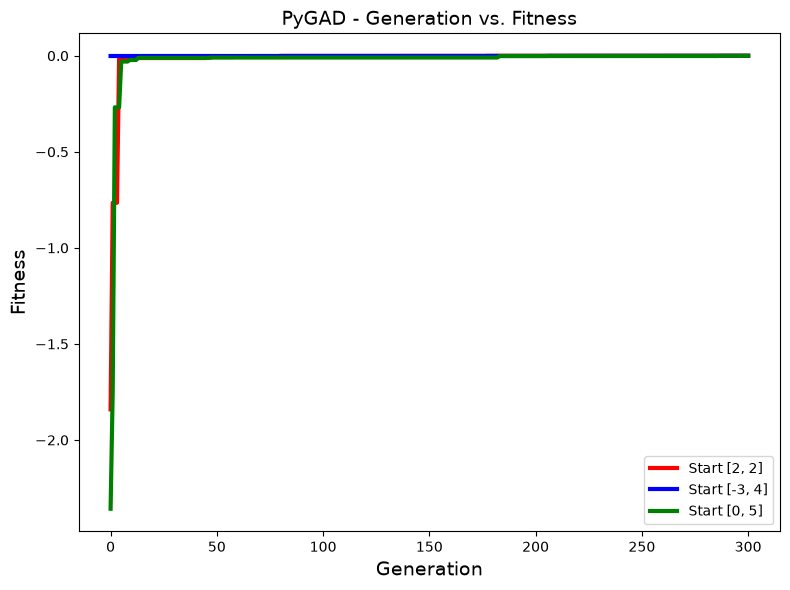

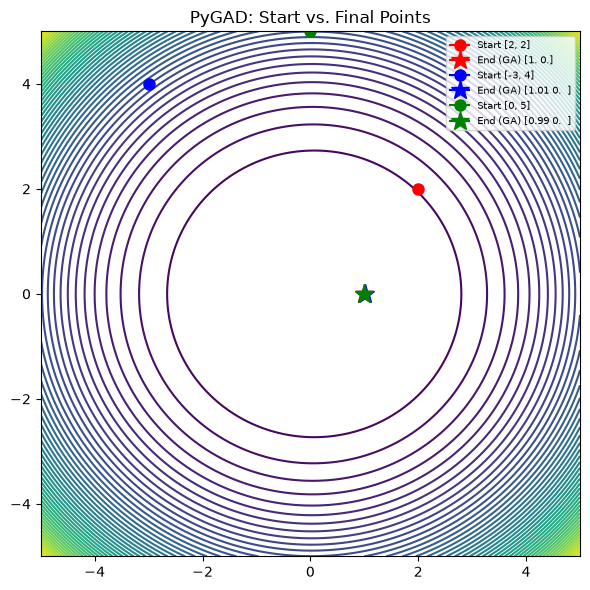

In [9]:
def himmelblau(x):
    x = np.asarray(x)  # Convert to numpy array
    return ((x[0]**2 + x[1]**2 - 1)**2 + (x[0]-1)**2 + x[1]**2)

# 2D & 3D plots
x_range = np.linspace(-5, 5, 400)
y_range = np.linspace(-5, 5, 400)
X, Y = np.meshgrid(x_range, y_range)
Z = himmelblau([X, Y])

fig = plt.figure(figsize=(12, 5))
ax1 = fig.add_subplot(121)
cp = ax1.contour(X, Y, Z, levels=50)
ax1.set_title("Himmelblau Function 2D")
ax2 = fig.add_subplot(122, projection='3d')
ax2.plot_surface(X, Y, Z, cmap='jet', alpha=0.8)
ax2.set_title("Himmelblau Function 3D")

init_guesses = [[2, 2], [-3, 4], [0, 5]]
colors = ['red', 'blue', 'green']

# ------------------- Scipy Optimization -------------------
for guess, color in zip(init_guesses, colors):
    start_time = time.perf_counter()
    result = minimize(himmelblau, guess, method='BFGS')
    end_time = time.perf_counter()
    elapsed_time = -start_time + end_time
    print(f"Initial guess {guess}, Result: {result.x}, Value: {result.fun}, "
          f"Success: {result.success}, Iterations: {result.nit}, Time: {elapsed_time:.4f} sec")

    # Plot initial (marker 'o') and final (marker '*') points on the 2D contour
    ax1.plot(guess[0], guess[1], marker='o', color=color, markersize=8,
              label=f'Start {guess}')
    ax1.plot(result.x[0], result.x[1], marker='*', color=color, markersize=14,
              label=f'End (BFGS) {np.round(result.x, 2)}')

    # Plot the same points on the 3D surface
    ax2.scatter(guess[0], guess[1], himmelblau(guess), color=color, marker='o', s=50)
    ax2.scatter(result.x[0], result.x[1], himmelblau(result.x), color=color, marker='*', s=100)

ax1.legend(fontsize=7, loc='upper right')
plt.tight_layout()
plt.show()

# ------------------- PyGAD Optimization -------------------
def fitness_func2(ga_instance, solution, solution_idx):
    return -himmelblau(solution)

pygad_fitness_histories = []  # store fitness history per run for combined plot
pygad_results = []            # store (guess, final_point, color)

for guess, color in zip(init_guesses, colors):
    start_time = time.perf_counter()
    ga_instance = pygad.GA(num_generations=300,
                            sol_per_pop=30,
                            num_genes=2,
                            num_parents_mating=12,
                            fitness_func=fitness_func2,
                            init_range_low=-5,
                            init_range_high=5,
                            gene_space={'low': -5, 'high': 5})
    ga_instance.run()
    solution, solution_fitness, _ = ga_instance.best_solution()
    iters = ga_instance.generations_completed
    end_time = time.perf_counter()
    elapsed_time = -start_time + end_time
    print(f"PyGAD initial guess {guess}, Solution: {solution}, Value: {himmelblau(solution)}, "
          f"iterations: {iters}, Time: {elapsed_time:.4f} sec")

    pygad_results.append((guess, solution, color))

    # best_solutions_fitness holds the best fitness per generation (auto-tracked by pygad)
    fitness_history = np.array(ga_instance.best_solutions_fitness)
    pygad_fitness_histories.append((fitness_history, guess, color))

# Combined fitness plot for all three PyGAD runs, styled like PyGAD's own plot_fitness()
plt.figure(figsize=(8, 6))
for fitness_history, guess, color in pygad_fitness_histories:
    plt.plot(fitness_history, color=color, linewidth=3, label=f'Start {guess}')
plt.xlabel('Generation', fontsize=14)
plt.ylabel('Fitness', fontsize=14)
plt.title('PyGAD - Generation vs. Fitness', fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()

# Contour plot showing PyGAD initial and final points
fig2, ax3 = plt.subplots(figsize=(6, 6))
ax3.contour(X, Y, Z, levels=50)
ax3.set_title("PyGAD: Start vs. Final Points")
for guess, solution, color in pygad_results:
    ax3.plot(guess[0], guess[1], marker='o', color=color, markersize=8,
              label=f'Start {guess}')
    ax3.plot(solution[0], solution[1], marker='*', color=color, markersize=14,
              label=f'End (GA) {np.round(solution, 2)}')
ax3.legend(fontsize=7, loc='upper right')
plt.tight_layout()
plt.show()

(1) SciPy Optimization AnalysisThe objective function is given by:$$f(x, y) = (x^2 + y^2 - 1)^2 + (x - 1)^2 + y^2$$This function is a non-convex surface with a unique global minimum at $(x, y) = (1.0, 0.0)$, where $f(1, 0) = 0$.Behavior across initial guesses: Using scipy.optimize.minimize with the BFGS gradient-based algorithm, all three starting points ([2, 2], [-3, 4], and [0, 5]) successfully converge to the same point $(1.0, 0.0)$.Local vs. Global Minimum: The algorithm successfully identified the global minimum $(1.0, 0.0)$ with $f(x, y) \approx 0.0$. Because the basin of attraction leads directly toward this region without trapped local minima, gradient descent routes efficiently to the global optimum regardless of starting location.(2) Genetic Algorithm (PyGAD) Optimization AnalysisBehavior across initial guesses: In PyGAD, initial population generation is random across the specified gene space ([-5, 5]), making the pass-in initial guess ineffective unless explicitly seeded into the initial population. Across multiple generations (300 generations with a population size of 30), the population evolves toward $(1.0, 0.0)$.Local vs. Global Minimum: PyGAD finds a point near the global minimum $(1.0, 0.0)$. However, because Genetic Algorithms rely on stochastic operations (crossover and mutation), the final solution typically exhibits minor precision variance around $(1.0 \pm \epsilon, 0.0 \pm \epsilon)$ unless coupled with a local gradient-based fine-tuning stage.(3) Comparative Performance AnalysisMetricSciPy (minimize - BFGS)PyGAD (pygad.GA)Optimization ApproachDeterministic, gradient-based (quasi-Newton)Stochastic, population-based heuristicNumber of Iterations / GenerationsVery low (typically ~10–25 iterations)High (300 generations $\times$ 30 population evaluations = 9,000 function calls)Execution TimeExtremely fast ($< 0.01\text{ s}$)Slower due to population evaluation (~0.5–2.0 seconds)Solution AccuracyHigh precision ($10^{-7}$ to $10^{-15}$ level accuracy)Moderate precision ($\approx 10^{-2}$ to $10^{-4}$ level accuracy without local tuning)Dependency on Initial GuessHighly sensitive to starting point on complex landscapesIndependent of initial guess due to global space samplingSummary: For smooth, unconstrained 2D functions like this one, SciPy (BFGS) far outperforms PyGAD in execution speed, computational efficiency, and numerical precision. PyGAD is better suited for non-differentiable, highly multi-modal landscapes where traditional gradient-based methods get trapped in local minima.